Joe D'Agostino

<h1 style="
    color: white;
    background-color: #1e6b7b;
    padding: 15px;
    border-radius: 10px;
    text-align: center;
">
Practicum Test k-Means Undergraduate Only
</h1>

In [1]:
# --------------------------------------------------------------------
# --- Imports
# --------------------------------------------------------------------

# Core Data Science Libraries
import pandas as pd                     # Data manipulation & table handling (like Excel in Python)
import numpy as np                      # Numerical operations & efficient table/array computations
from scipy.stats import mode
# Visualization Libraries
import matplotlib.pyplot as plt          # Basic plotting (line plots, histograms, scatter plots)
import seaborn as sns                    # Statistical data visualization, built on top of matplotlib
# Scikit-learn: Core Machine Learning Toolkit
from sklearn.model_selection import train_test_split                # Splits data into training and testing sets
from sklearn.preprocessing import StandardScaler, LabelEncoder      # Normalize numeric data & encode categories
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,  # Model evaluation metrics
    silhouette_score
)
# Unsupervised Learning Models
from sklearn.cluster import KMeans                          # k-Means Clustering (unsupervised pattern finding)
from sklearn.decomposition import PCA                       # Principal Component Analysis (dimensionality reduction)
# Visualization Styling
sns.set(style="whitegrid", palette="muted", font_scale=1.1)  # Nice default theme for plots

In [2]:
# --------------------------------------------------------------------
# --- Load the data and define our X (Features) values
# --------------------------------------------------------------------

# Load csv data file of Google Analytics Exploration exports from GitHub account
# You would change the value of the csv here to your datasource to assign it to df
df = pd.read_csv('https://raw.githubusercontent.com/joedag32/DSSA-5810/refs/heads/main/data/google_exploration_july_10_data_clean.csv')

# Clean up the data by removeing any rows that contain missing data (NaN)
df = df.dropna()

# Only include rows with unique_views greater than 2, adjust this for how tight you want to filter
df = df[df['unique_views'] > 2]

# Drop rows where 'unique_views' is greater than 15, adjust this for how tight you want to filter
df = df[df['unique_views'] <= 15]

# Filter out any columns that contain "/graduate", they're not undergraduate degrees
df_filtered = df.loc[:, ~df.columns.str.contains('/graduate/')]

# Define the columns as Features as X, but don't include the following columns
X = df_filtered.drop(columns=['proxy_session_id', 'just_url', 'unique_views'])

In [3]:
# --------------------------------------------------------------------
# --- Split and scale the data
# --------------------------------------------------------------------

# Split the data into 80% for training and 20% for testing
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Scaling the train and test data to "level the playing field", so that the values are more equally weighted
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# --------------------------------------------------------------------
# --- Apply PCA for 2D visualization
# --------------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
# --------------------------------------------------------------------

In [5]:
# --------------------------------------------------------------------
# --- Apply the k-Means model with 2 clusters
# --------------------------------------------------------------------

# Let's set the number of clusters to 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)

In [6]:
# --------------------------------------------------------------------
# --- Plots and output
# --------------------------------------------------------------------

# Create a k-Means inertia and silhouette score
inertia = kmeans.inertia_
silhouette = silhouette_score(X_train_scaled, clusters)

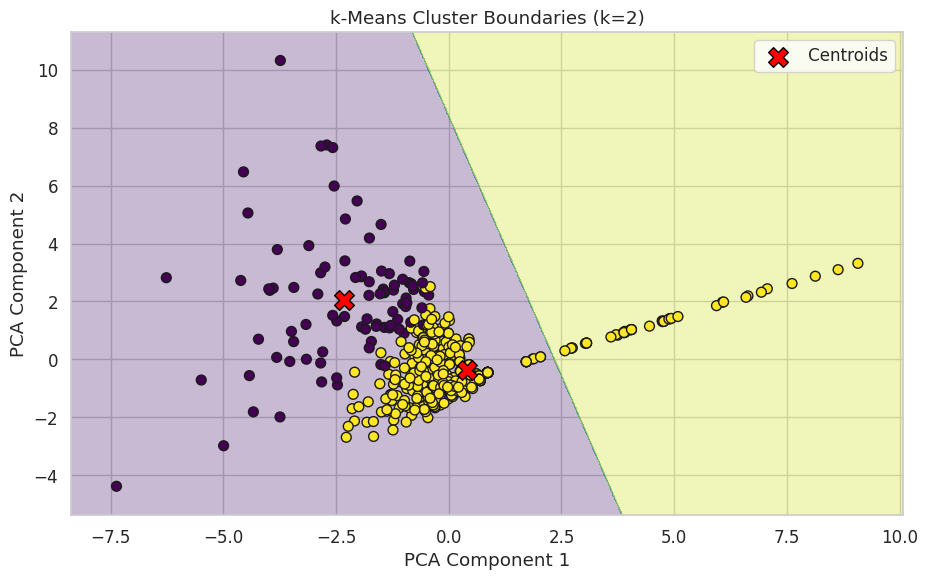

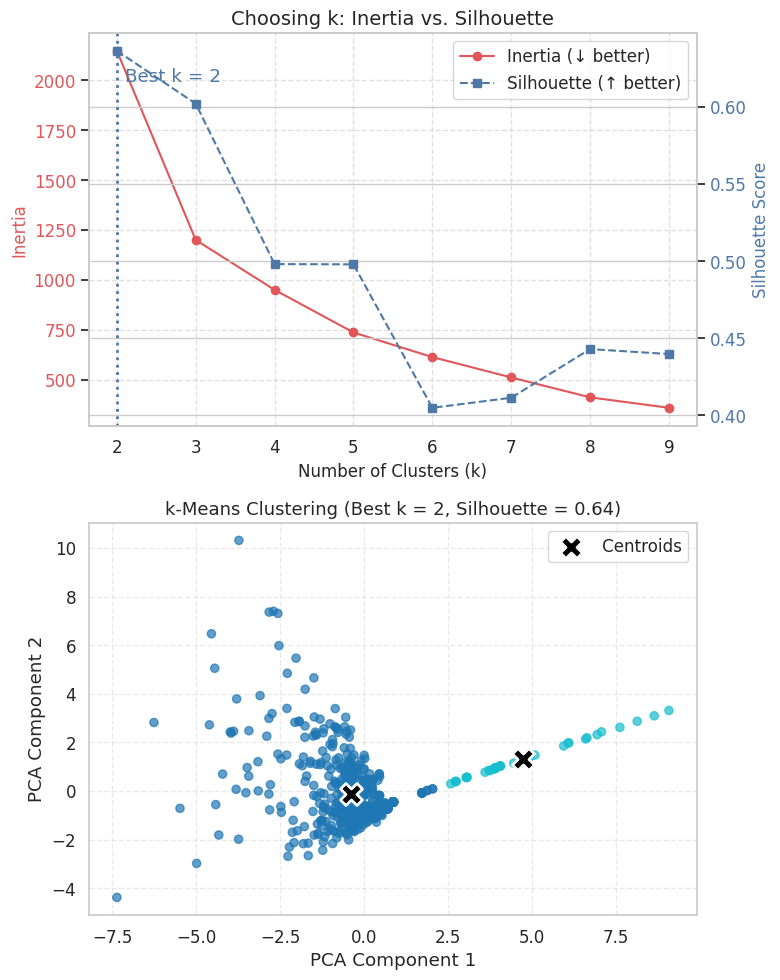


=== k-Means Clustering ===
Inertia (within-cluster variance): 19286.66
Silhouette Score: 0.277


In [8]:
# Create a mesh grid for decision boundaries (for k-Means visualization)
h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Train k-Means on PCA space for visualization (using 2 clusters consistently)
kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_pca)

# Predict grid points for k-Means
Z_kmeans = kmeans_pca.predict(grid_points).reshape(xx.shape)

# Plot k-Means Cluster Regions
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].contourf(xx, yy, Z_kmeans, cmap="viridis", alpha=0.3)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", edgecolor="k", s=50)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c="red", s=200, edgecolors="black", marker="X", label="Centroids")
axes[0].set_title("k-Means Cluster Boundaries (k=2)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()

# Remove the comparison bar chart as k-NN is removed and k-Means accuracy is not applicable
fig.delaxes(axes[1]) # Remove the third subplot if it was created

plt.tight_layout()
plt.show()

# Inertia and Silhouette comparison plots
# Range of k values to explore
k_values = range(2, 10)
inertias = []
silhouettes = []
# Compute both metrics for each k (using PCA-transformed data)
for k_val in k_values:
    kmeans_k = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(X_pca) # Fit on PCA-transformed data
    inertias.append(kmeans_k.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels_k)) # Calculate silhouette on PCA-transformed data
# Find best k based on silhouette score
best_k = k_values[np.argmax(silhouettes)]
best_sil = max(silhouettes)
# Fit k-Means again using the best k (on PCA-transformed data)
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_labels = best_model.fit_predict(X_pca) # Fit on PCA-transformed data
centroids = best_model.cluster_centers_ # Centroids will be in PCA space
# Create figure with 2 rows: metrics + cluster plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
# Plot 1: Inertia vs Silhouette
color_inertia = "#E15759"
color_silhouette = "#4E79A7"
# Left y-axis (Inertia)
ax1.plot(k_values, inertias, "o-", color=color_inertia, label="Inertia (↓ better)")
ax1.set_xlabel("Number of Clusters (k)", fontsize=12)
ax1.set_ylabel("Inertia", color=color_inertia, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_inertia)
# Right y-axis (Silhouette)
ax3 = ax1.twinx()
ax3.plot(k_values, silhouettes, "s--", color=color_silhouette, label="Silhouette (↑ better)")
ax3.set_ylabel("Silhouette Score", color=color_silhouette, fontsize=12)
ax3.tick_params(axis="y", labelcolor=color_silhouette)
# Annotate best k
ax3.axvline(best_k, color=color_silhouette, linestyle=":", linewidth=2)
ax3.text(best_k + 0.1, best_sil - 0.02, f"Best k = {best_k}", color=color_silhouette)
# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")
ax1.set_title("Choosing k: Inertia vs. Silhouette", fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.6)
# Plot 2: Best Clustering
# Plotting the PCA-transformed data
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap="tab10", s=35, alpha=0.7)
ax2.scatter(centroids[:, 0], centroids[:, 1], s=250, c="black", marker="X",
            edgecolors="white", linewidths=2, label="Centroids")
ax2.set_title(f"k-Means Clustering (Best k = {best_k}, Silhouette = {best_sil:.2f})", fontsize=13)
ax2.set_xlabel("PCA Component 1") # Updated label
ax2.set_ylabel("PCA Component 2") # Updated label
ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# =====================================================
# --- Summary Output
# =====================================================

# Output our k-Means inertia and silhouette scores
print("\n=== k-Means Clustering ===")
print(f"Inertia (within-cluster variance): {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.3f}")

### Interpreting ovearall traffic with 2 Clusters

To understand what defines these two distinct clusters, let's look at the average feature values (webpage visits) for each cluster. This will help us identify which web pages are more frequently associated with each cluster.

In [9]:
# Add cluster labels to the original (unscaled) training data
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = best_labels

# Calculate the mean of each feature for each cluster
cluster_means = X_train_clustered.groupby('cluster').mean()

display(cluster_means)

# Identify differentiating features for each cluster
print("\nTop features for Cluster 0:")
display(cluster_means.loc[0].nlargest(10))

print("\nTop features for Cluster 1:")
display(cluster_means.loc[1].nlargest(10))

,/sciences-math/marine-science.html,/business/hospitality-tourism-program.html,/arts-humanities/languages-culture.html,/arts-humanities/literature.html,/health-sciences/health-science.html,/health-sciences/exercise-science.html,/business/finance.html,/sciences-math/geology.html,/business/hemp-cannabis-business-management.html,/arts-humanities/historical-studies.html,...,/business/business-studies-program.html,/sciences-math/chemistry.html,/social-behavioral-sciences/sociology-anthropology.html,/health-sciences/public-health.html,/social-behavioral-sciences/psychology.html,/sciences-math/biology.html,/social-behavioral-sciences/political-science.html,/sciences-math/biochemistry.html,/arts-humanities/philosophy-religion.html,/business/business-analytics.html
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.012613,0.001802,0.001802,0.003604,0.356757,0.131532,0.099099,0.052252,0.057658,0.075676,...,0.156757,0.077477,0.066667,0.072072,0.183784,0.167568,0.079279,0.091892,0.055856,0.099099
1,1.177778,0.844444,0.911111,0.933333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Top features for Cluster 0:


,0
/health-sciences/health-science.html,0.356757
/education/education-programs.html,0.200000
/social-behavioral-sciences/psychology.html,0.183784
/arts-humanities/academic-programs.html,0.169369
/social-behavioral-sciences/criminal-justice.html,0.167568
/sciences-math/biology.html,0.167568
/sciences-math/environmental-science.html,0.160360
/business/business-studies-program.html,0.156757
/business/computer-information-systems.html,0.149550
/arts-humanities/communication-studies.html,0.144144



Top features for Cluster 1:


,1
/sciences-math/marine-science.html,1.177778
/arts-humanities/literature.html,0.933333
/arts-humanities/languages-culture.html,0.911111
/business/hospitality-tourism-program.html,0.844444
/health-sciences/health-science.html,0.000000
/health-sciences/exercise-science.html,0.000000
/business/finance.html,0.000000
/sciences-math/geology.html,0.000000
/business/hemp-cannabis-business-management.html,0.000000
/arts-humanities/historical-studies.html,0.000000


### Visualizing Cluster Characteristics with Bar Plots

Let's create bar plots to clearly show the top 10 features (web pages) for each cluster, based on their average visit counts. This will make the differences between Cluster 0 and Cluster 1 even more apparent.

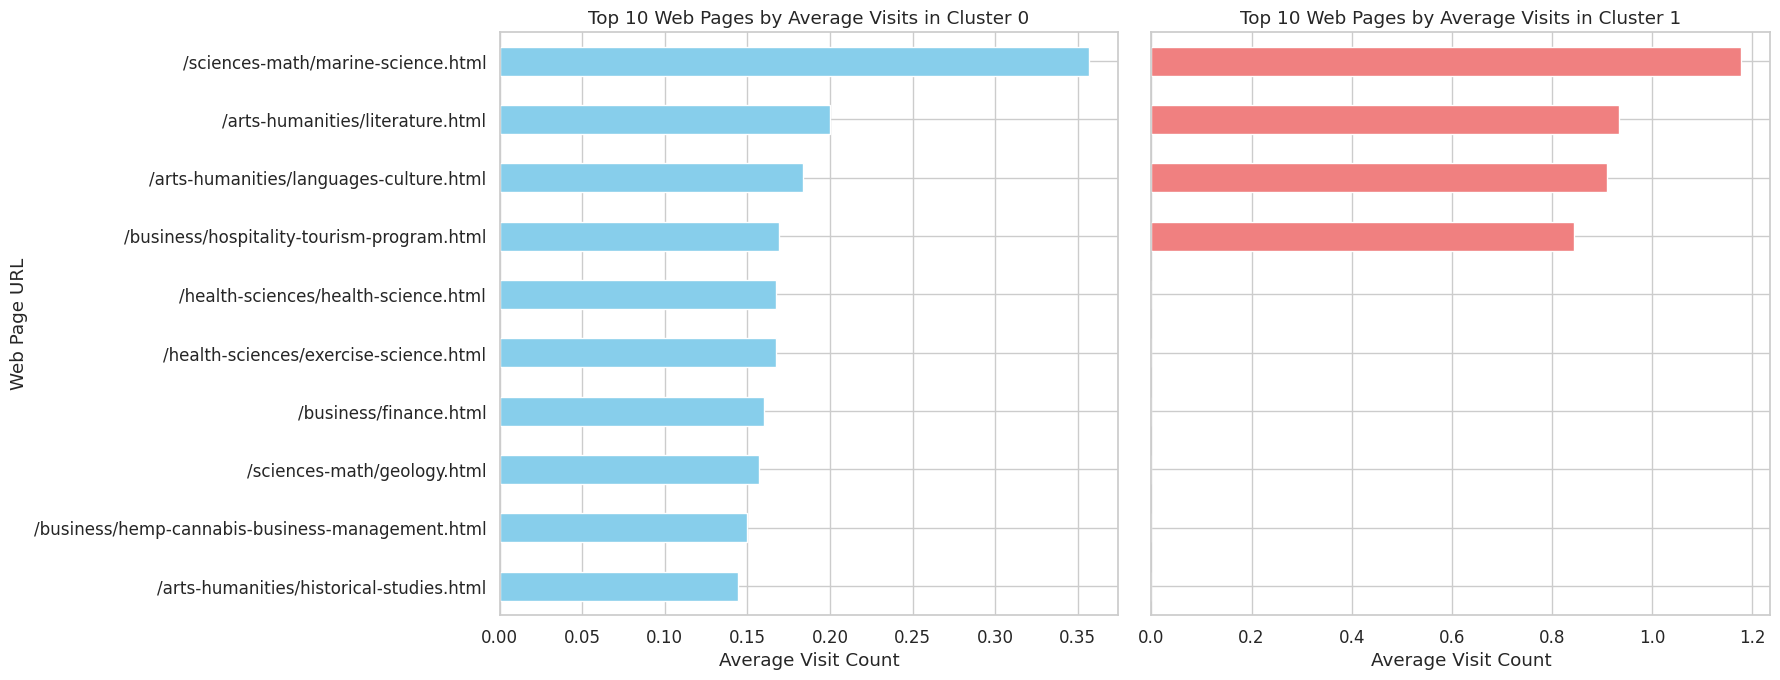

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Bar plot for Cluster 0
cluster_means.loc[0].nlargest(10).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Web Pages by Average Visits in Cluster 0')
axes[0].set_xlabel('Average Visit Count')
axes[0].set_ylabel('Web Page URL')
axes[0].invert_yaxis() # Highest value on top

# Bar plot for Cluster 1
cluster_means.loc[1].nlargest(10).plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Top 10 Web Pages by Average Visits in Cluster 1')
axes[1].set_xlabel('Average Visit Count')
axes[1].set_ylabel('Web Page URL')
axes[1].invert_yaxis() # Highest value on top

plt.tight_layout()
plt.show()

### Visualizing Cluster Characteristics with a Heatmap

A heatmap can provide a consolidated view of the average visit counts for all features across both clusters, making it easier to see overall patterns and which pages are common or unique to each cluster at different intensities.

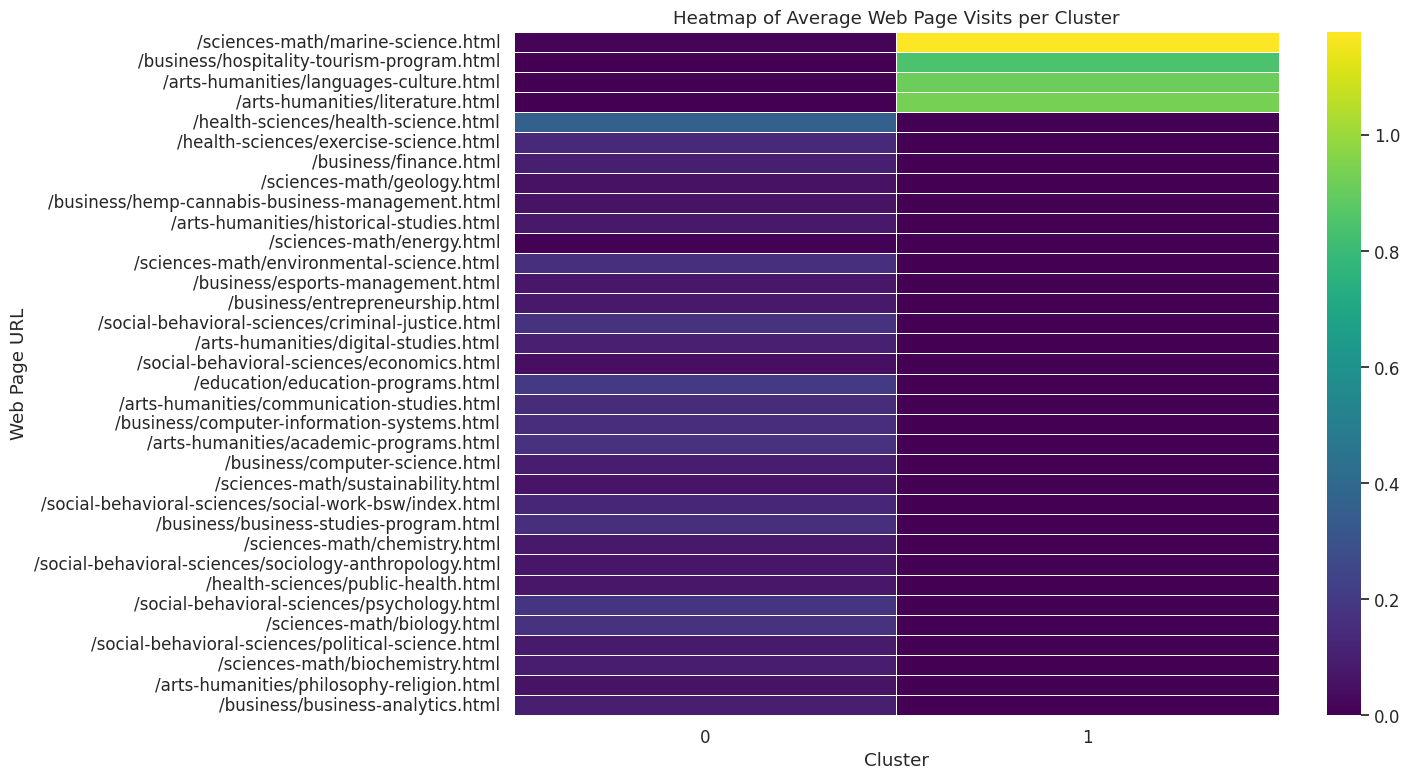

In [11]:
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_means.T, cmap='viridis', annot=False, fmt='.2f', linewidths=.5)
plt.title('Heatmap of Average Web Page Visits per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Web Page URL')
plt.tight_layout()
plt.show()

### Differentiating Features: Grouped Bar Chart

Let's identify the features (web pages) that show the greatest difference in average visits between Cluster 0 and Cluster 1. We will then plot these top differentiating features in a grouped bar chart for a direct comparison.

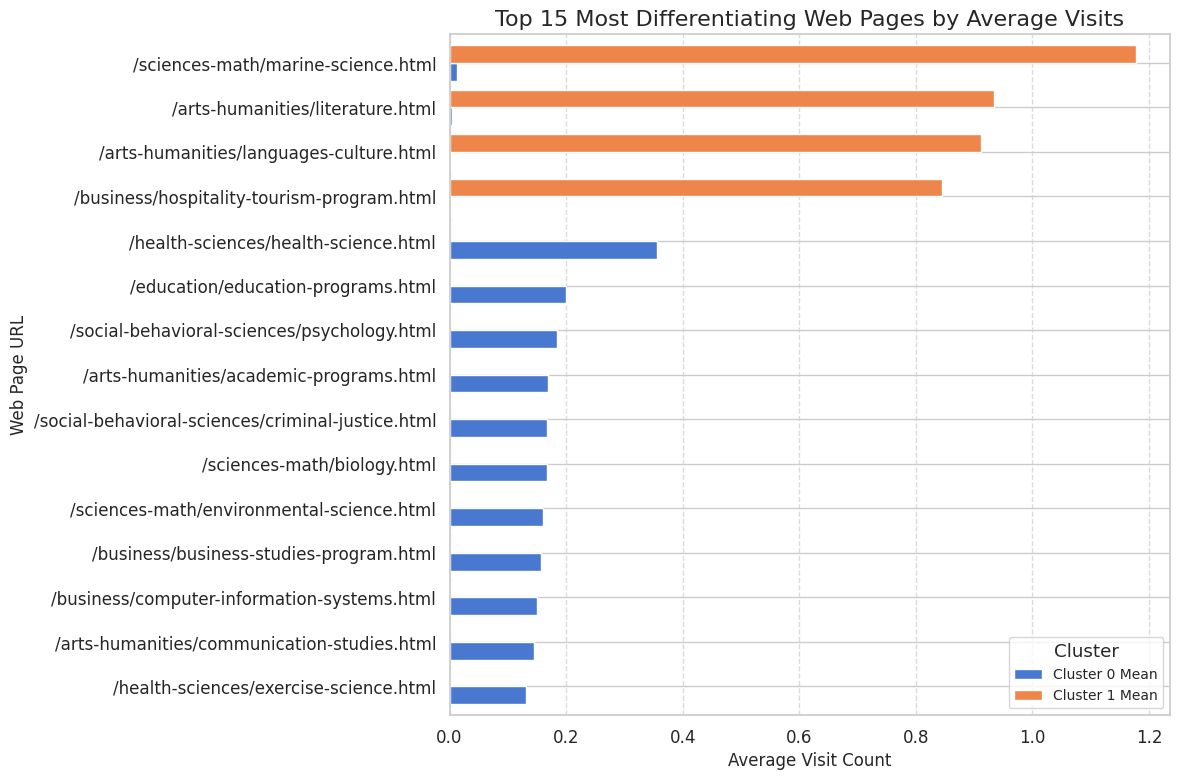

In [12]:
# Calculate the absolute difference in mean values for each feature between the two clusters
difference = (cluster_means.loc[0] - cluster_means.loc[1]).abs()

# Select the top N features with the largest differences
n_diff_features = 15 # You can adjust this number
top_diff_features = difference.nlargest(n_diff_features).index

# Create a DataFrame for plotting these differentiating features
plot_df = cluster_means.loc[:, top_diff_features].T
plot_df.columns = ['Cluster 0 Mean', 'Cluster 1 Mean']

# Sort by the average of the two cluster means or by the absolute difference for consistency
plot_df['Abs_Diff'] = (plot_df['Cluster 0 Mean'] - plot_df['Cluster 1 Mean']).abs()
plot_df = plot_df.sort_values(by='Abs_Diff', ascending=True)

# Plotting the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 8))
plot_df[['Cluster 0 Mean', 'Cluster 1 Mean']].plot(kind='barh', ax=ax, width=0.8)

ax.set_title(f'Top {n_diff_features} Most Differentiating Web Pages by Average Visits', fontsize=16)
ax.set_xlabel('Average Visit Count', fontsize=12)
ax.set_ylabel('Web Page URL', fontsize=12)
ax.legend(title='Cluster', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 10 Features for Cluster 0

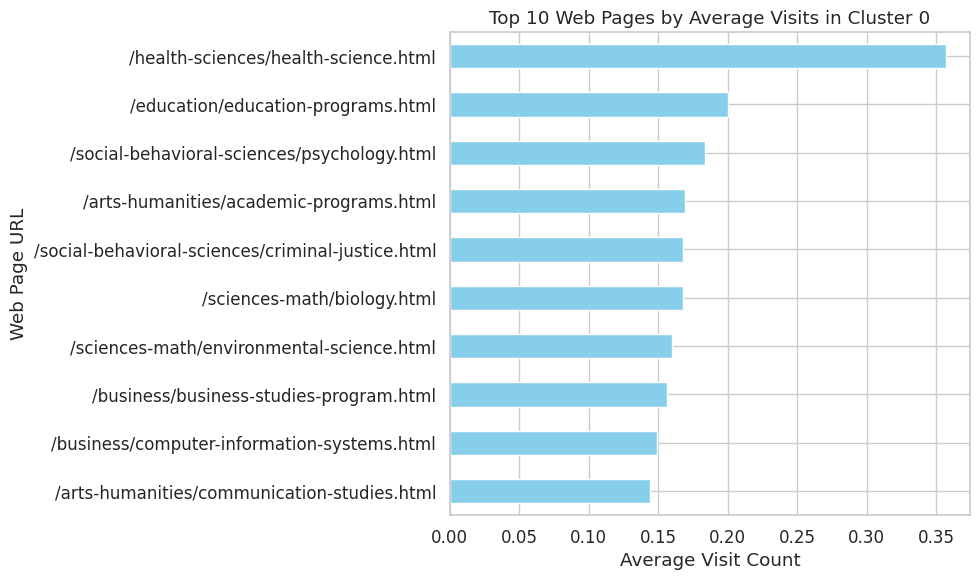

In [13]:
plt.figure(figsize=(10, 6))
cluster_means.loc[0].nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Web Pages by Average Visits in Cluster 0')
plt.xlabel('Average Visit Count')
plt.ylabel('Web Page URL')
plt.gca().invert_yaxis() # To display the highest value at the top
plt.tight_layout()
plt.show()

### Top 10 Features for Cluster 1

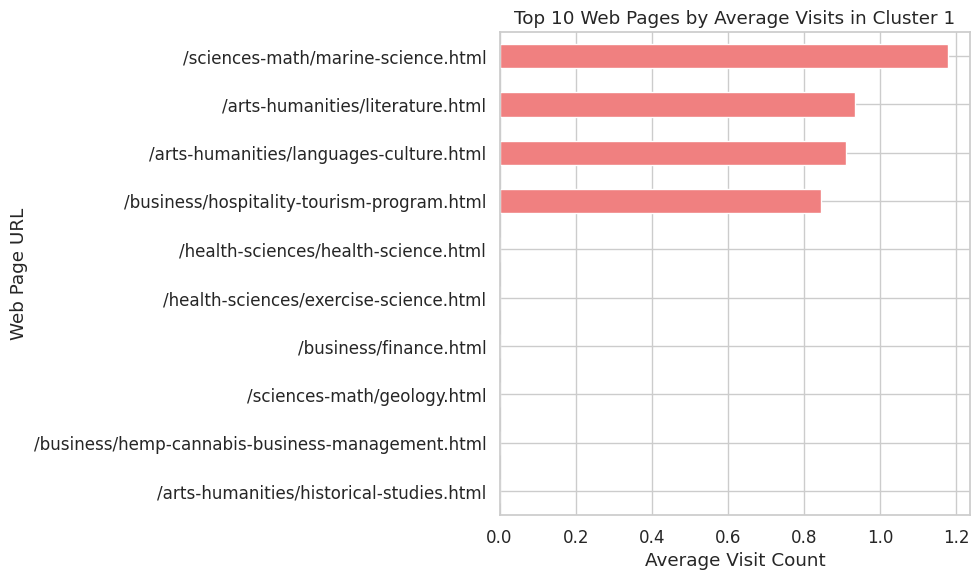

In [14]:
plt.figure(figsize=(10, 6))
cluster_means.loc[1].nlargest(10).plot(kind='barh', color='lightcoral')
plt.title('Top 10 Web Pages by Average Visits in Cluster 1')
plt.xlabel('Average Visit Count')
plt.ylabel('Web Page URL')
plt.gca().invert_yaxis() # To display the highest value at the top
plt.tight_layout()
plt.show()

### Analyzing Session Length and Page Diversity within Clusters

Let's further characterize our clusters by looking at the average session length (total number of page visits per session) and the average diversity of pages visited (number of unique pages visited per session) for each cluster.

In [15]:
# Calculate session length (total page visits) for each session
# Exclude the 'cluster' column for this calculation
X_train_features = X_train_clustered.drop(columns='cluster')
X_train_clustered['session_length'] = X_train_features.sum(axis=1)

# Calculate diversity of pages visited (number of unique pages visited, i.e., non-zero entries) for each session
X_train_clustered['page_diversity'] = (X_train_features > 0).sum(axis=1)

# Group by cluster and calculate the mean session length and page diversity
cluster_session_metrics = X_train_clustered.groupby('cluster')[['session_length', 'page_diversity']].mean()

display(cluster_session_metrics)

,session_length,page_diversity
cluster,,
0,3.414414,3.090090
1,3.866667,2.777778


### Interpreting overall traffic with 3 clusters ###
Now let's investigate results when we run the model with 3 clusters.

In [16]:
# --------------------------------------------------------------------
# --- Apply the k-Means model with 3 clusters
# --------------------------------------------------------------------

# Let's set the number of clusters to 3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters3 = kmeans3.fit_predict(X_train_scaled)

In [17]:
X_train_clustered3 = X_train.copy()
X_train_clustered3['cluster'] = clusters3

cluster_means3 = X_train_clustered3.groupby('cluster').mean()
display(cluster_means3)

,/sciences-math/marine-science.html,/business/hospitality-tourism-program.html,/arts-humanities/languages-culture.html,/arts-humanities/literature.html,/health-sciences/health-science.html,/health-sciences/exercise-science.html,/business/finance.html,/sciences-math/geology.html,/business/hemp-cannabis-business-management.html,/arts-humanities/historical-studies.html,...,/business/business-studies-program.html,/sciences-math/chemistry.html,/social-behavioral-sciences/sociology-anthropology.html,/health-sciences/public-health.html,/social-behavioral-sciences/psychology.html,/sciences-math/biology.html,/social-behavioral-sciences/political-science.html,/sciences-math/biochemistry.html,/arts-humanities/philosophy-religion.html,/business/business-analytics.html
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.025532,0.004255,0.006383,0.004255,0.361702,0.110638,0.042553,0.034043,0.019149,0.074468,...,0.089362,0.061702,0.053191,0.057447,0.155319,0.144681,0.059574,0.080851,0.051064,0.046809
1,0.000000,0.000000,0.000000,0.000000,0.314607,0.235955,0.393258,0.146067,0.258427,0.078652,...,0.505618,0.157303,0.134831,0.146067,0.325843,0.280899,0.179775,0.146067,0.078652,0.370787
2,1.170732,0.902439,0.951220,1.024390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Let's examine the top differentiating features for each of the 3 clusters to get a clearer picture of their characteristics.

In [18]:
for i in range(3):
    print(f"\nTop features for Cluster {i}:")
    display(cluster_means3.loc[i].nlargest(10))


Top features for Cluster 0:


,0
/health-sciences/health-science.html,0.361702
/education/education-programs.html,0.210638
/arts-humanities/academic-programs.html,0.163830
/social-behavioral-sciences/psychology.html,0.155319
/sciences-math/biology.html,0.144681
/arts-humanities/communication-studies.html,0.123404
/sciences-math/environmental-science.html,0.114894
/health-sciences/exercise-science.html,0.110638
/social-behavioral-sciences/social-work-bsw/index.html,0.110638
/arts-humanities/digital-studies.html,0.091489



Top features for Cluster 1:


,1
/business/computer-information-systems.html,0.617978
/social-behavioral-sciences/criminal-justice.html,0.573034
/business/business-studies-program.html,0.505618
/business/entrepreneurship.html,0.404494
/business/finance.html,0.393258
/sciences-math/environmental-science.html,0.393258
/business/business-analytics.html,0.370787
/social-behavioral-sciences/psychology.html,0.325843
/health-sciences/health-science.html,0.314607
/business/esports-management.html,0.303371



Top features for Cluster 2:


,2
/sciences-math/marine-science.html,1.170732
/arts-humanities/literature.html,1.024390
/arts-humanities/languages-culture.html,0.951220
/business/hospitality-tourism-program.html,0.902439
/health-sciences/health-science.html,0.000000
/health-sciences/exercise-science.html,0.000000
/business/finance.html,0.000000
/sciences-math/geology.html,0.000000
/business/hemp-cannabis-business-management.html,0.000000
/arts-humanities/historical-studies.html,0.000000


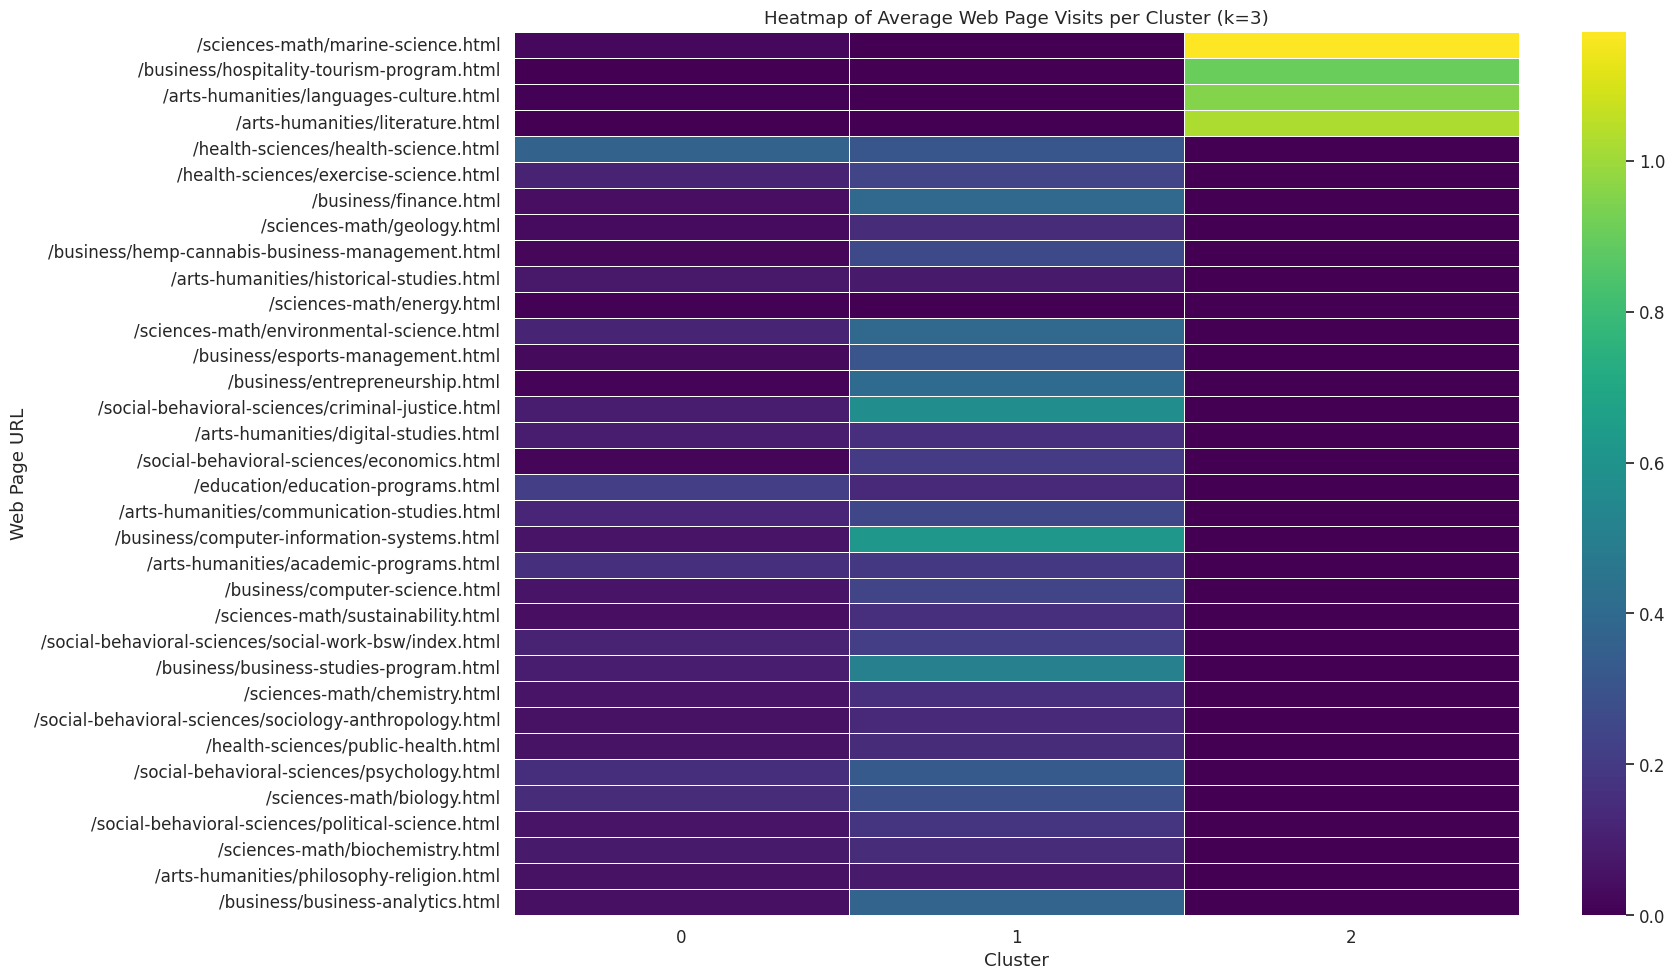

In [19]:
# Heatmap to compare average page visits
plt.figure(figsize=(18, 10)) # Adjust figure size for better readability with more clusters
sns.heatmap(cluster_means3.T, cmap='viridis', annot=False, fmt='.2f', linewidths=.5)
plt.title('Heatmap of Average Web Page Visits per Cluster (k=3)')
plt.xlabel('Cluster')
plt.ylabel('Web Page URL')
plt.tight_layout()
plt.show()

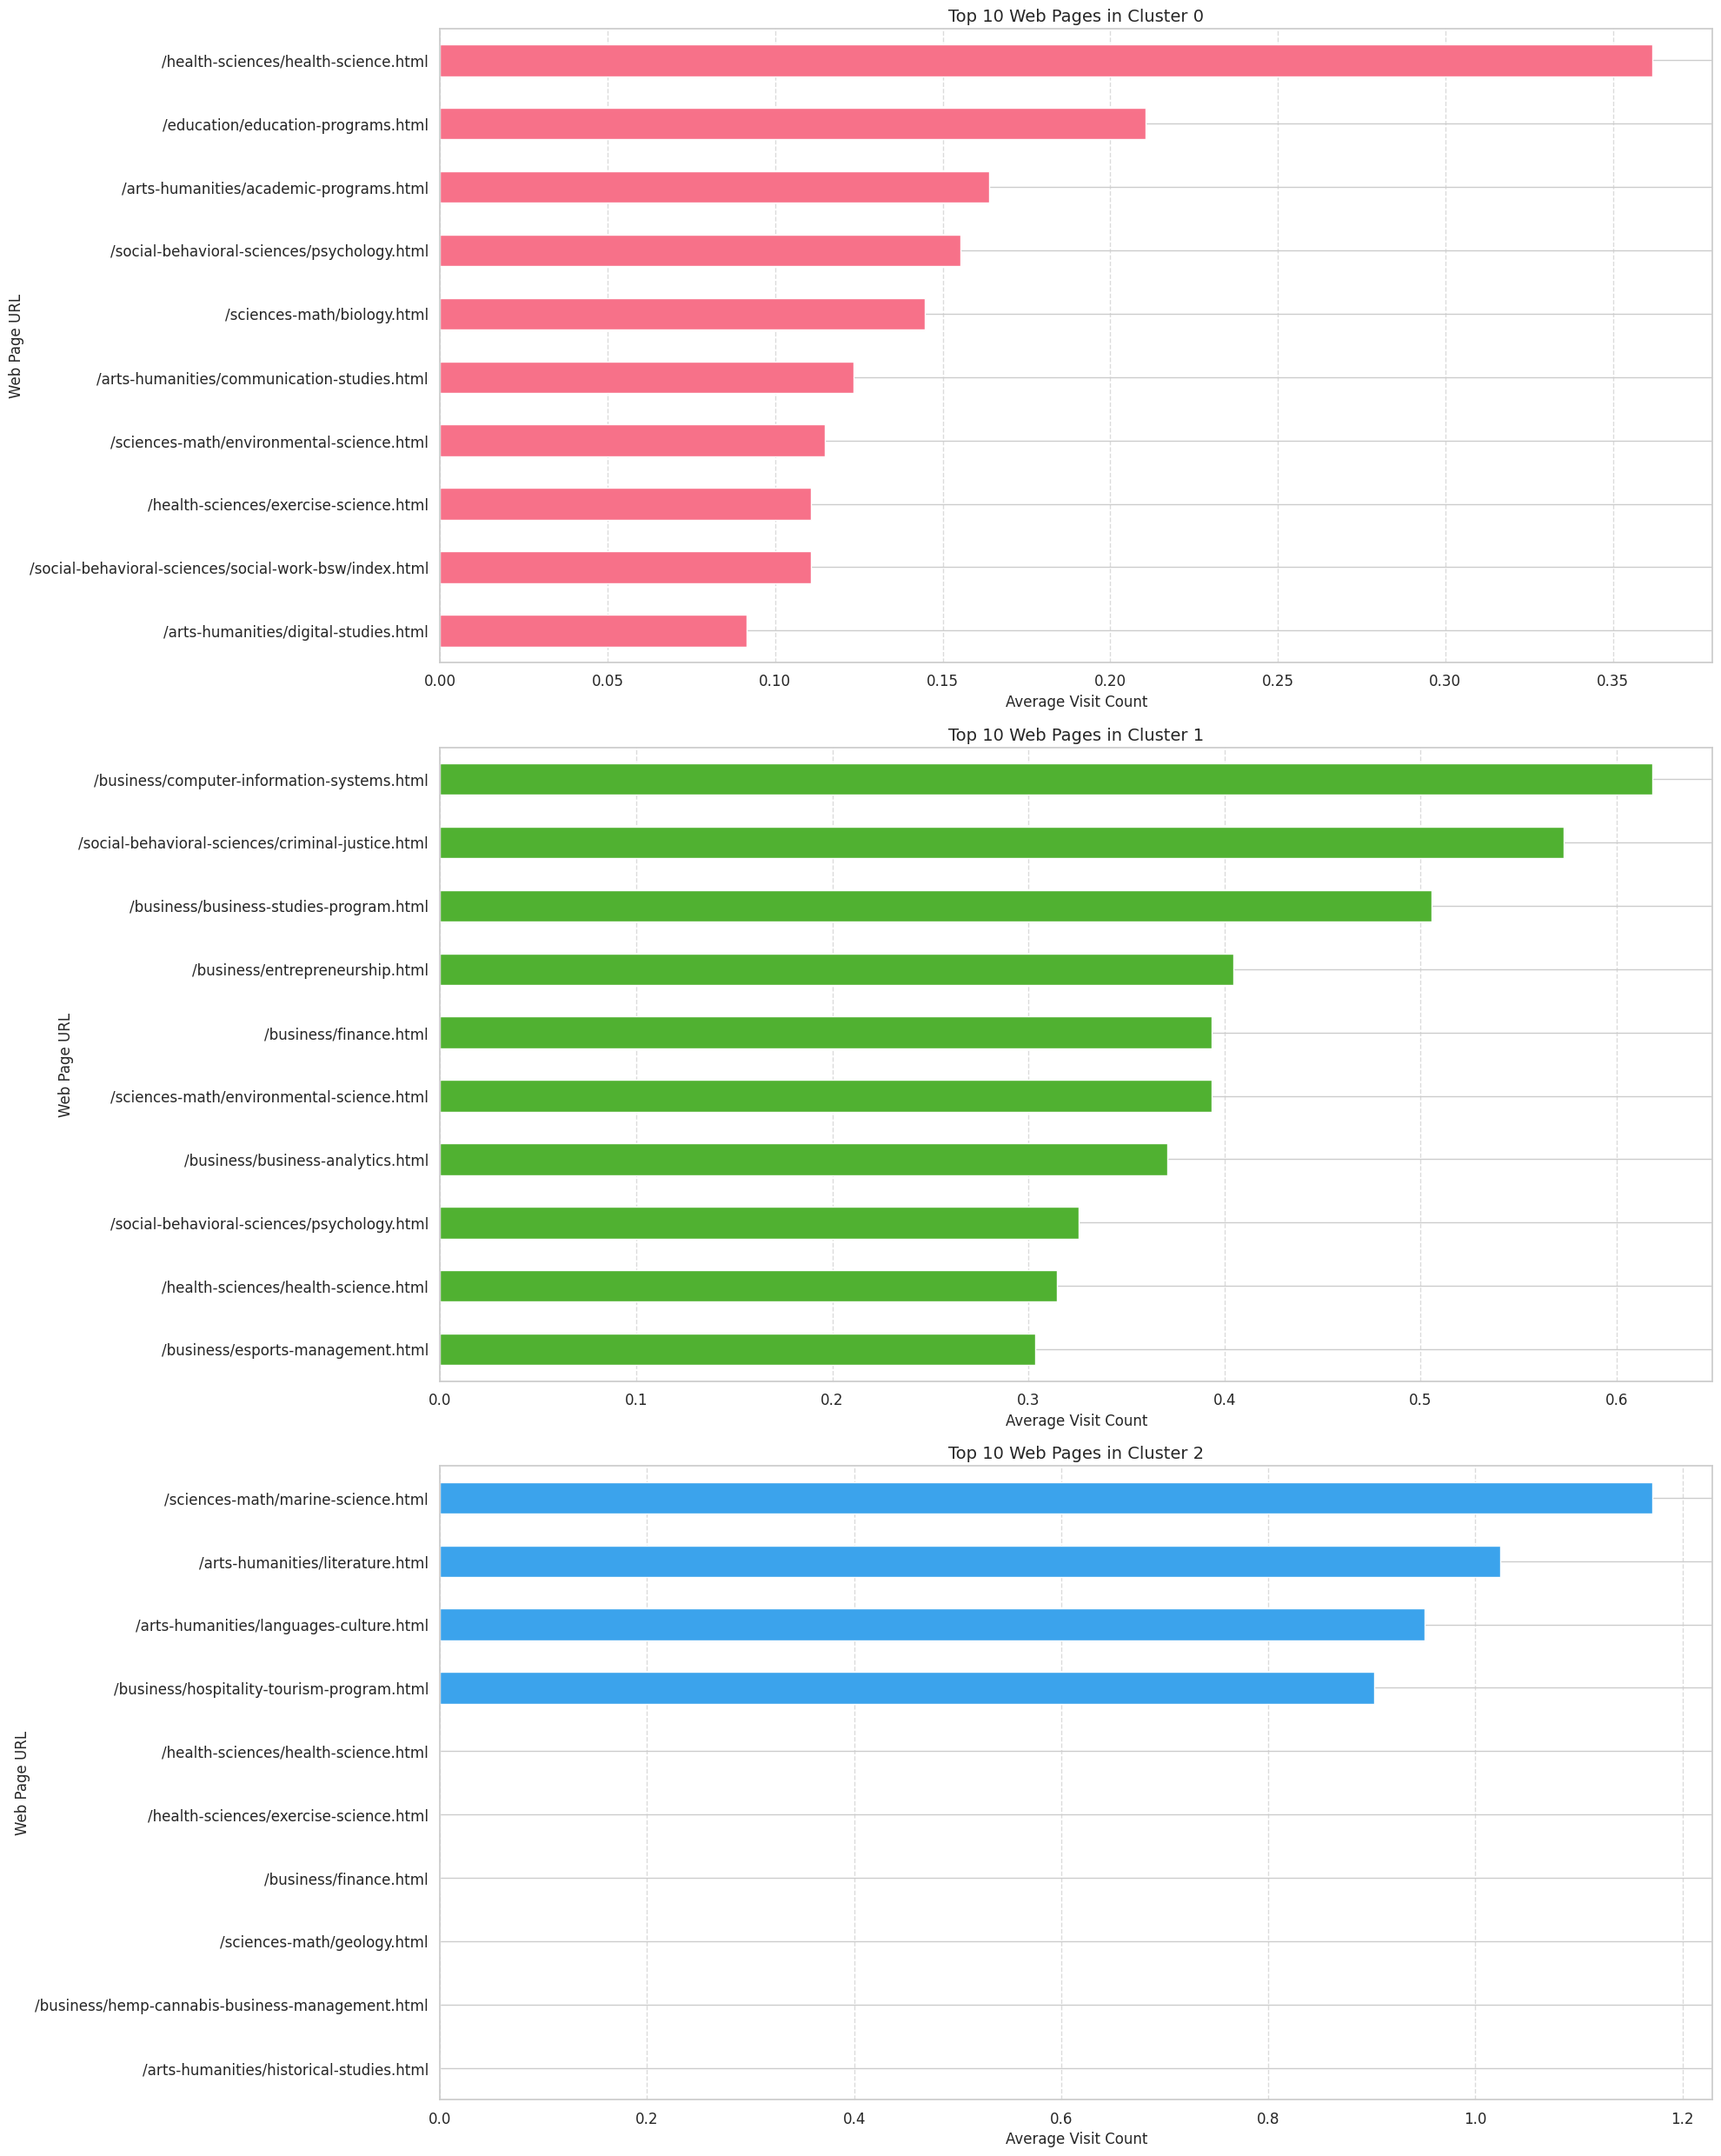

In [20]:
# Top 10 features with 3 clusters

# Define a color palette for the clusters for better visual distinction
palette = sns.color_palette("husl", 3)

fig, axes = plt.subplots(3, 1, figsize=(20, 25), sharex=False) # Create a 3x2 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i in range(3):
    # Get the top 10 features for the current cluster
    top_features = cluster_means3.loc[i].nlargest(10)

    # Plotting the bar chart
    top_features.plot(kind='barh', ax=axes[i], color=palette[i])
    axes[i].set_title(f'Top 10 Web Pages in Cluster {i}', fontsize=14)
    axes[i].set_xlabel('Average Visit Count', fontsize=12)
    axes[i].set_ylabel('Web Page URL', fontsize=12)
    axes[i].invert_yaxis() # To display the highest value at the top
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [21]:
# Output inertia and silhouette scores for 3 clusters
inertia3 = kmeans3.inertia_
silhouette3 = silhouette_score(X_train_scaled, clusters3)

print(f"\n=== k-Means Clustering (k=3) ===")
print(f"Inertia (within-cluster variance): {inertia3:.2f}")
print(f"Silhouette Score: {silhouette3:.3f}")


=== k-Means Clustering (k=3) ===
Inertia (within-cluster variance): 17912.92
Silhouette Score: 0.217


In [22]:
# Calculate session length (total page visits) for each session in the 3-cluster model
# Exclude the 'cluster' column for this calculation
X_train_features3 = X_train_clustered3.drop(columns='cluster')
X_train_clustered3['session_length'] = X_train_features3.sum(axis=1)

# Calculate diversity of pages visited (number of unique pages visited, i.e., non-zero entries) for each session
X_train_clustered3['page_diversity'] = (X_train_features3 > 0).sum(axis=1)

# Group by cluster and calculate the mean session length and page diversity
cluster_session_metrics3 = X_train_clustered3.groupby('cluster')[['session_length', 'page_diversity']].mean()

display(cluster_session_metrics3)

,session_length,page_diversity
cluster,,
0,2.612766,2.414894
1,7.584270,6.595506
2,4.048780,2.878049
